# 🔍 Customer Churn Prediction — Gold Layer
## Machine Learning Pipeline dengan Random Forest

> **Tujuan:** Membangun model prediksi churn untuk mengidentifikasi pelanggan berisiko tinggi meninggalkan layanan, menggunakan data RFM dari Gold Layer dan profil pelanggan dari Silver Layer.

---

| Info | Detail |
|------|--------|
| **Layer** | Gold |
| **Algoritma** | Random Forest Classifier |
| **Target Variable** | Churn Label (`recency > 90 hari` → Churn) |
| **Fitur Input** | Frequency, Monetary, Tenure, Opt-in Channel |
| **Sumber Data** | `s3a://gold/rfm_segments` + `s3a://silver/integrated_sales` |

---

### Alur Pipeline

```
[Silver Layer]      [Gold RFM Layer]
  Profil          +  Recency, Freq,    →  Feature    →  Random    →  Insight
  Pelanggan          Monetary              Matrix        Forest       Bisnis
```

---

## ⚙️ 1. Environment Setup

In [1]:
from ingestion.spark_client import get_spark_session

RFM_GOLD_PATH = "s3a://gold/rfm_segments"
SILVER_PATH = "s3a://silver/integrated_sales/"
CHURN_GOLD_PATH = "s3a://gold/churn_predictions"

spark = get_spark_session(app_name="Churn-Prediction-Gold")
print("Spark Session ready.")

Spark Session ready.


---

## 📦 2. Data Preparation & Feature Engineering

### Strategi Labeling Churn
Pelanggan dianggap **churn** jika **Recency > 90 hari** (tidak bertransaksi selama 3 bulan terakhir).

```
Recency > 90 hari  →  label = 1  (Churn / Kabur)
Recency ≤ 90 hari  →  label = 0  (Aktif / Bertahan)
```

### Fitur yang Digunakan

| Fitur | Sumber | Keterangan |
|-------|--------|------------|
| `frequency` | Gold RFM | Total transaksi pelanggan |
| `monetary` | Gold RFM | Total nilai belanja |
| `tenure_days` | Silver | Lama menjadi pelanggan (hari) |
| `email_opt_in` | Silver | Apakah berlangganan email? |
| `sms_opt_in` | Silver | Apakah berlangganan SMS? |
| `call_opt_in` | Silver | Apakah berlangganan telepon? |

In [2]:
from pyspark.sql import functions as F

# 1. Load Data Gold (Hasil RFM)
df_gold = spark.read.parquet(RFM_GOLD_PATH)

# 2. Tentukan Label Churn (Y) berdasarkan ambang batas 90 hari
# 1 = Churn, 0 = Active
df_labeled = df_gold.withColumn(
    "label", 
    F.when(F.col("recency") > 90, 1).otherwise(0)
)

# 3. Load Data Silver (Fitur Profil)
# Kita ambil fitur statis/profil dari data Silver
df_silver = spark.read.parquet(SILVER_PATH)

# Agregasi level customer untuk mendapatkan fitur profil unik
df_profiles = df_silver.groupBy("customer_id").agg(
    F.first("email_opt_in").alias("email_opt_in"),
    F.first("sms_opt_in").alias("sms_opt_in"),
    F.first("call_opt_in").alias("call_opt_in"),
    F.min("invoice_date").alias("first_purchase") # Untuk hitung Tenure
)

# 4. Join Gold dan Silver
# Simpan segment dan recency untuk analisis serta output gold hasil scoring
df_final_model = df_labeled.select("customer_id", "segment", "recency", "label", "frequency", "monetary") \
    .join(df_profiles, "customer_id", "inner")

# 5. Hitung Tenure (Sudah berapa lama mereka jadi pelanggan dalam hari)
max_date = df_silver.select(F.max("invoice_date")).collect()[0][0]
df_final_model = df_final_model.withColumn(
    "tenure_days", 
    F.datediff(F.lit(max_date), F.col("first_purchase"))
)

df_final_model.show(5)

+-----------+---------+-------+-----+---------+--------+------------+----------+-----------+--------------+-----------+
|customer_id|  segment|recency|label|frequency|monetary|email_opt_in|sms_opt_in|call_opt_in|first_purchase|tenure_days|
+-----------+---------+-------+-----+---------+--------+------------+----------+-----------+--------------+-----------+
|        833|     Lost|    183|    1|        1|    20.5|           0|         0|          1|    2015-02-13|       3974|
|       2142|  At Risk|    285|    1|        1|   100.0|           1|         1|          0|    2015-02-06|       3981|
|       4519|  At Risk|    139|    1|        1|    52.0|           0|         0|          0|    2015-02-21|       3966|
|       4900|  At Risk|     80|    0|        1|    60.5|           0|         0|          0|    2025-10-12|         80|
|       5300|Champions|     77|    0|        3|    66.5|           0|         0|          0|    2015-03-27|       3932|
+-----------+---------+-------+-----+---

---

## 🤖 3. Model Configuration — Random Forest

### Mengapa Random Forest?

| Keunggulan | Penjelasan |
|-----------|------------|
| **Robust terhadap Outlier** | Data transaksi sering mengandung nilai ekstrem |
| **Feature Importance** | Memberikan ranking fitur penyebab churn |
| **Tidak Perlu Normalisasi** | Bekerja baik dengan skala fitur yang berbeda |
| **Menghindari Overfitting** | Ensemble dari banyak pohon = lebih general |

### Konfigurasi Model
- `numTrees = 100` — 100 pohon untuk stabilitas prediksi
- `maxDepth = 10` — Kedalaman maks agar tidak overfitting
- `train:test = 80:20` — Split standar untuk evaluasi generalisasi

In [3]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# 1. Menyiapkan Fitur (X)
# Ingat: Kita tidak memasukkan 'recency' dan 'customer_id' ke sini
input_cols = ["frequency", "monetary", "tenure_days", "email_opt_in", "sms_opt_in", "call_opt_in"]

assembler = VectorAssembler(inputCols=input_cols, outputCol="features")
final_data = assembler.transform(df_final_model)

# 2. Split Data (80% Pelatihan, 20% Pengujian)
# Seed=42 digunakan agar hasilnya konsisten saat dijalankan ulang
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)

# 3. Konfigurasi Model Random Forest
# numTrees: 100 pohon untuk akurasi yang stabil
# maxDepth: 10 tingkat kedalaman agar tidak terlalu menghafal data (overfitting)
rf = RandomForestClassifier(
    labelCol="label", 
    featuresCol="features", 
    numTrees=100, 
    maxDepth=10, 
    seed=42
)


---

## 🏋️ 4. Model Training & Evaluation

Model dilatih pada 80% data. Evaluasi dilakukan dengan tiga metrik:

| Metrik | Interpretasi |
|--------|-------------|
| **AUC (Area Under ROC)** | Kemampuan model membedakan churn vs aktif. `> 0.8` = Sangat Baik |
| **Accuracy** | Persentase prediksi yang benar secara keseluruhan |
| **F1 Score** | Keseimbangan antara Precision dan Recall |
| **Confusion Matrix** | Detail True Positive, False Negative, dll |

In [4]:
import pandas as pd
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Training
print("🌲 Membangun Random Forest Model...")
rf_model = rf.fit(train_data)

# Prediksi
predictions = rf_model.transform(test_data)

# Evaluasi multi-metrik
evaluator_auc = BinaryClassificationEvaluator(labelCol="label")
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

auc      = evaluator_auc.evaluate(predictions)
accuracy = evaluator_acc.evaluate(predictions)
f1_score = evaluator_f1.evaluate(predictions)

# Confusion Matrix
pred_pd = predictions.select("label", "prediction").toPandas()
cm = pd.crosstab(
    pred_pd["label"].map({0: "Aktif (0)", 1: "Churn (1)"}),
    pred_pd["prediction"].map({0.0: "Pred: Aktif", 1.0: "Pred: Churn"}),
    rownames=["Aktual"],
    colnames=["Prediksi"],
    margins=True,
    margins_name="Total"
)

# Report
rating = "🟢 Sangat Baik" if auc > 0.85 else "🟡 Baik" if auc > 0.75 else "🔴 Perlu Ditingkatkan"

print(f"\n{'═'*52}")
print(f"          📋  MODEL PERFORMANCE REPORT")
print(f"{'═'*52}")
print(f"  📈  AUC Score    :  {auc:.4f}   {rating}")
print(f"  🎯  Accuracy     :  {accuracy:.4f}   ({accuracy*100:.1f}%)")
print(f"  ⚖️   F1 Score     :  {f1_score:.4f}")
print(f"{'═'*52}")
print(f"\n📋 Confusion Matrix:\n")
print(cm.to_string())
print(f"\n💡 Interpretasi:")
print(f"   • True Positives  : Model benar mendeteksi pelanggan churn")
print(f"   • False Negatives : Pelanggan churn yang TIDAK terdeteksi (risiko terbesar)")
print(f"   • False Positives : Pelanggan aktif yang salah diklasifikasikan churn")

🌲 Membangun Random Forest Model...

════════════════════════════════════════════════════
          📋  MODEL PERFORMANCE REPORT
════════════════════════════════════════════════════
  📈  AUC Score    :  0.8316   🟡 Baik
  🎯  Accuracy     :  0.8723   (87.2%)
  ⚖️   F1 Score     :  0.8498
════════════════════════════════════════════════════

📋 Confusion Matrix:

Prediksi   Pred: Aktif  Pred: Churn  Total
Aktual                                    
Aktif (0)         1394         2807   4201
Churn (1)          371        20311  20682
Total             1765        23118  24883

💡 Interpretasi:
   • True Positives  : Model benar mendeteksi pelanggan churn
   • False Negatives : Pelanggan churn yang TIDAK terdeteksi (risiko terbesar)
   • False Positives : Pelanggan aktif yang salah diklasifikasikan churn


---

## 📊 5. Feature Importance Analysis

> **Pertanyaan Bisnis:** *Faktor apa yang paling mempengaruhi seorang pelanggan untuk churn?*

Feature Importance mengukur seberapa besar kontribusi setiap fitur dalam keputusan model. Semakin tinggi nilainya, semakin krusial fitur tersebut dalam memprediksi churn.

🏆 Peringkat Fitur Penyebab Churn:

Rank  Fitur                            Kontribusi Bar
------------------------------------------------------------
  #1   Lama Berlangganan (Tenure)         81.4%   ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  #2   Frekuensi Belanja                  14.3%   █████████████████████
  #3   Total Nilai Transaksi               3.4%   █████
  #4   Opt-in SMS                          0.3%   
  #5   Opt-in Telepon                      0.3%   
  #6   Opt-in Email                        0.3%   


/tmp/ipykernel_2892/877009016.py:67: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2892/877009016.py:68: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig('feature_importance_churn.png', dpi=150, bbox_inches='tight')
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


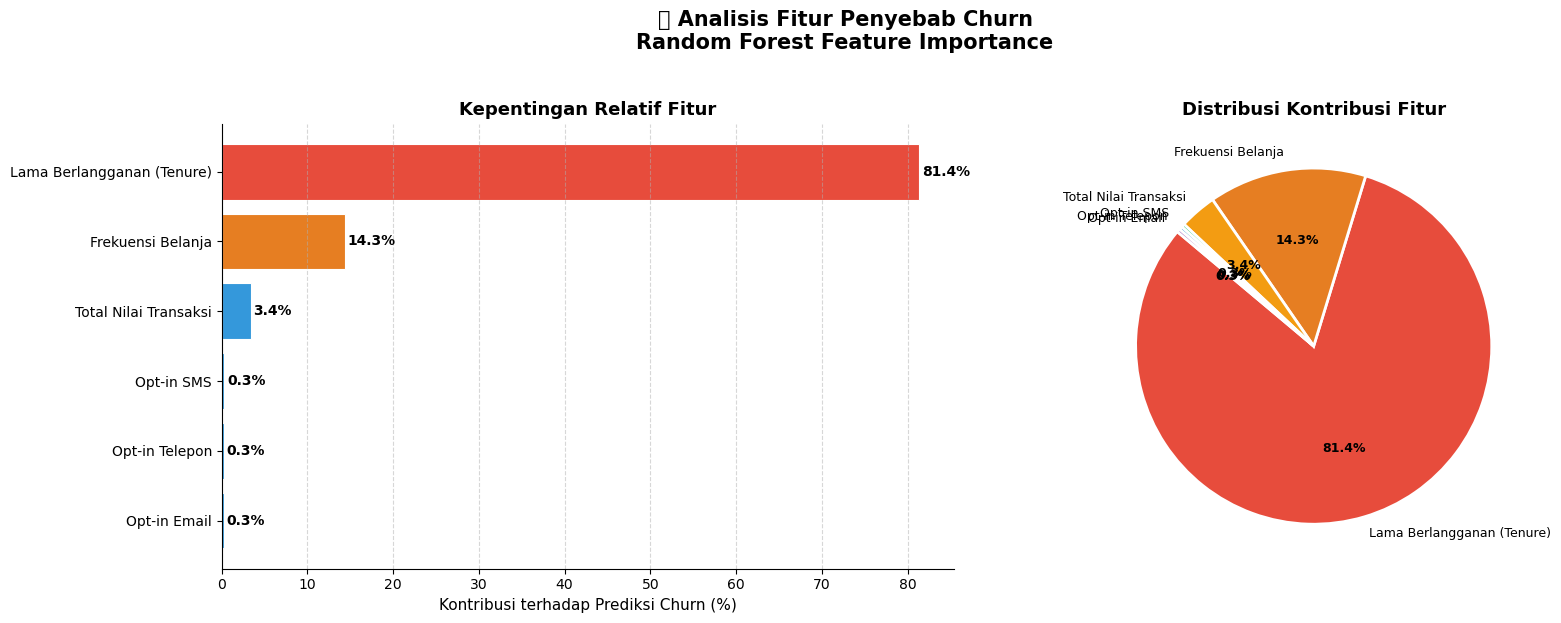


✅ Chart tersimpan: feature_importance_churn.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# 1. Ambil feature importances
importances = rf_model.featureImportances.toArray()
label_map = {
    'frequency': 'Frekuensi Belanja',
    'monetary': 'Total Nilai Transaksi',
    'tenure_days': 'Lama Berlangganan (Tenure)',
    'email_opt_in': 'Opt-in Email',
    'sms_opt_in': 'Opt-in SMS',
    'call_opt_in': 'Opt-in Telepon'
}

importance_df = pd.DataFrame({
    'Fitur': input_cols,
    'Label': [label_map[c] for c in input_cols],
    'Kepentingan': importances,
    'Persen': importances * 100
}).sort_values(by='Kepentingan', ascending=False).reset_index(drop=True)

# Print ranking
print("🏆 Peringkat Fitur Penyebab Churn:\n")
print(f"{'Rank':<5} {'Fitur':<30} {'Kontribusi':>12} {'Bar'}")
print("-" * 60)
for i, row in importance_df.iterrows():
    bar = "█" * int(row['Persen'] * 1.5)
    print(f"  #{i+1:<3} {row['Label']:<30} {row['Persen']:>8.1f}%   {bar}")

# 2. Visualisasi: dual panel
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('📊 Analisis Fitur Penyebab Churn\nRandom Forest Feature Importance',
             fontsize=15, fontweight='bold', y=1.03)

# Warna: merah = top 1, oranye = top 2, biru = sisanya
palette = ['#e74c3c', '#e67e22'] + ['#3498db'] * (len(importance_df) - 2)

# Panel kiri: Horizontal bar chart
bars = axes[0].barh(importance_df['Label'], importance_df['Persen'],
                     color=palette, edgecolor='white', linewidth=0.8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Kontribusi terhadap Prediksi Churn (%)', fontsize=11)
axes[0].set_title('Kepentingan Relatif Fitur', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
axes[0].spines[['top', 'right']].set_visible(False)
for bar, pct in zip(bars, importance_df['Persen']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=10, fontweight='bold')

# Panel kanan: Pie chart
wedge_colors = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']
wedges, texts, autotexts = axes[1].pie(
    importance_df['Persen'],
    labels=importance_df['Label'],
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Distribusi Kontribusi Fitur', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart tersimpan: feature_importance_churn.png")

---

## 🗺️ 6. Customer Segmentation Map

> **Pertanyaan Bisnis:** *Di segmen mana pelanggan yang paling rentan churn berkumpul? Apakah pelanggan baru atau lama yang lebih berisiko?*

Peta ini memvisualisasikan posisi setiap pelanggan berdasarkan **lama berlangganan (Tenure)** dan **frekuensi belanja** — diberi warna berdasarkan hasil prediksi model.

📊 Ringkasan Prediksi:
   Total Pelanggan   : 24,883
   Diprediksi Churn  : 23,118  (92.9%)
   Diprediksi Aktif  : 1,765  (7.1%)


/tmp/ipykernel_2892/3975213875.py:77: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2892/3975213875.py:78: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from current font.
  plt.savefig('customer_segmentation_map.png', dpi=150, bbox_inches='tight')
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


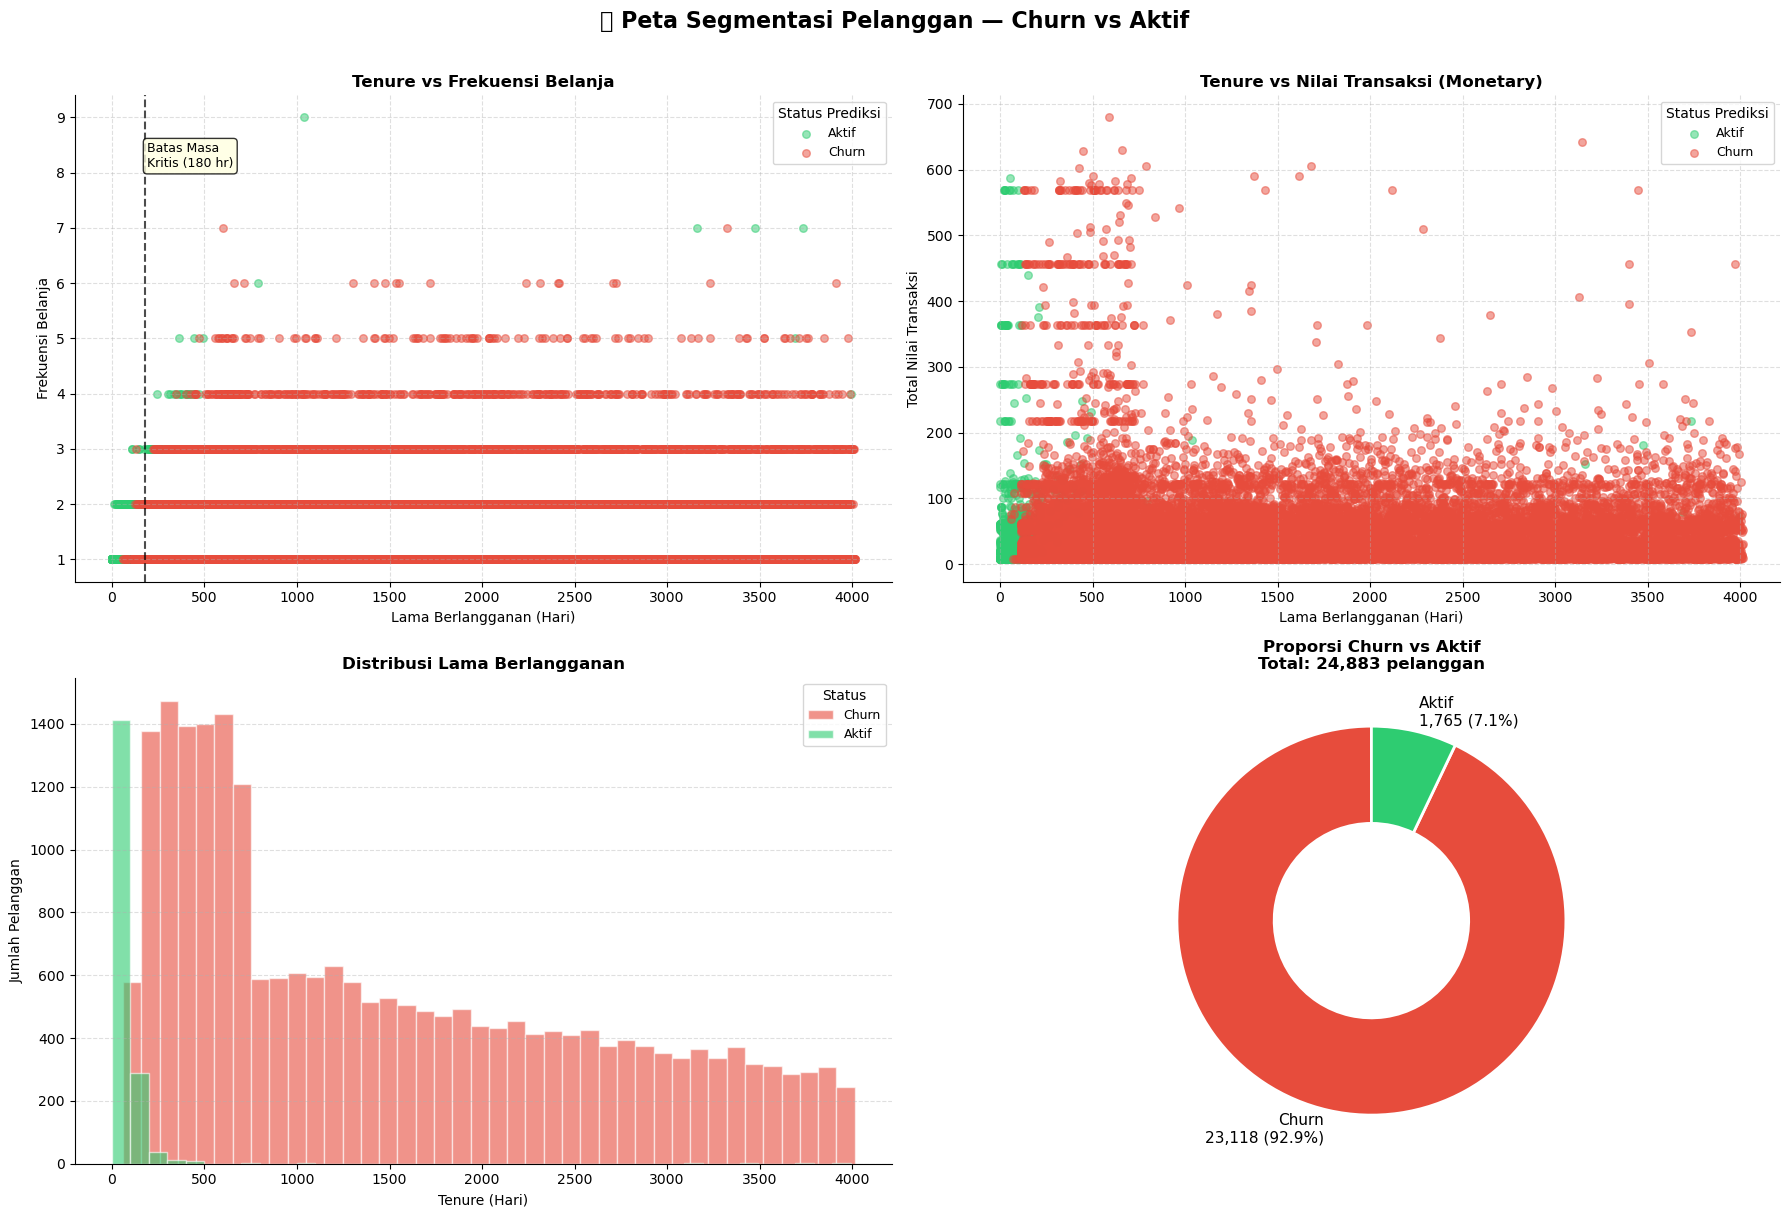


✅ Chart tersimpan: customer_segmentation_map.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# 1. Konversi ke Pandas untuk visualisasi
sample_df = predictions.select("tenure_days", "frequency", "monetary", "prediction", "label").toPandas()
sample_df['Status'] = sample_df['prediction'].map({1.0: 'Churn', 0.0: 'Aktif'})
sample_df['Aktual'] = sample_df['label'].map({1: 'Churn', 0: 'Aktif'})

# Statistik ringkas
total      = len(sample_df)
n_churn    = (sample_df['prediction'] == 1.0).sum()
n_aktif    = (sample_df['prediction'] == 0.0).sum()
churn_rate = n_churn / total * 100

print(f"📊 Ringkasan Prediksi:")
print(f"   Total Pelanggan   : {total:,}")
print(f"   Diprediksi Churn  : {n_churn:,}  ({churn_rate:.1f}%)")
print(f"   Diprediksi Aktif  : {n_aktif:,}  ({100-churn_rate:.1f}%)")

# 2. Layout 2x2 panel
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('🗺️ Peta Segmentasi Pelanggan — Churn vs Aktif',
             fontsize=16, fontweight='bold', y=1.01)

color_map = {'Churn': '#e74c3c', 'Aktif': '#2ecc71'}

# Panel 1: Tenure vs Frequency (Peta Utama)
for status, group in sample_df.groupby('Status'):
    axes[0, 0].scatter(group['tenure_days'], group['frequency'],
                       c=color_map[status], alpha=0.5, s=30, label=status)
axes[0, 0].axvline(x=180, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0, 0].text(190, sample_df['frequency'].max() * 0.9,
                'Batas Masa\nKritis (180 hr)', fontsize=9, color='black',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
axes[0, 0].set_title('Tenure vs Frekuensi Belanja', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Lama Berlangganan (Hari)', fontsize=10)
axes[0, 0].set_ylabel('Frekuensi Belanja', fontsize=10)
axes[0, 0].legend(title='Status Prediksi', fontsize=9)
axes[0, 0].grid(True, linestyle='--', alpha=0.4)
axes[0, 0].spines[['top', 'right']].set_visible(False)

# Panel 2: Tenure vs Monetary
for status, group in sample_df.groupby('Status'):
    axes[0, 1].scatter(group['tenure_days'], group['monetary'],
                       c=color_map[status], alpha=0.5, s=30, label=status)
axes[0, 1].set_title('Tenure vs Nilai Transaksi (Monetary)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Lama Berlangganan (Hari)', fontsize=10)
axes[0, 1].set_ylabel('Total Nilai Transaksi', fontsize=10)
axes[0, 1].legend(title='Status Prediksi', fontsize=9)
axes[0, 1].grid(True, linestyle='--', alpha=0.4)
axes[0, 1].spines[['top', 'right']].set_visible(False)

# Panel 3: Distribusi Tenure per Status (Histogram)
for status in ['Churn', 'Aktif']:
    subset = sample_df[sample_df['Status'] == status]['tenure_days']
    axes[1, 0].hist(subset, bins=40, alpha=0.6, label=status,
                    color=color_map[status], edgecolor='white')
axes[1, 0].set_title('Distribusi Lama Berlangganan', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tenure (Hari)', fontsize=10)
axes[1, 0].set_ylabel('Jumlah Pelanggan', fontsize=10)
axes[1, 0].legend(title='Status', fontsize=9)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.4)
axes[1, 0].spines[['top', 'right']].set_visible(False)

# Panel 4: Donut chart — proporsi Churn vs Aktif
sizes  = [n_churn, n_aktif]
labels = [f'Churn\n{n_churn:,} ({churn_rate:.1f}%)',
          f'Aktif\n{n_aktif:,} ({100-churn_rate:.1f}%)']
colors = ['#e74c3c', '#2ecc71']
wedges, _ = axes[1, 1].pie(sizes, labels=labels, colors=colors,
                             startangle=90, wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 2},
                             textprops={'fontsize': 11})
axes[1, 1].set_title(f'Proporsi Churn vs Aktif\nTotal: {total:,} pelanggan',
                      fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('customer_segmentation_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart tersimpan: customer_segmentation_map.png")

---

## 💾 7. Save to Gold Layer

Hasil scoring churn disimpan ke MinIO dalam format Parquet, dipartisi berdasarkan `predicted_status`
agar query downstream untuk pelanggan aktif vs churn lebih efisien.

In [7]:
from pyspark.ml.functions import vector_to_array

churn_predictions_gold = (
    predictions
    .withColumn("prediction", F.col("prediction").cast("int"))
    .withColumn("churn_probability", F.round(vector_to_array("probability")[1], 4))
    .withColumn("actual_status", F.when(F.col("label") == 1, F.lit("churn")).otherwise(F.lit("active")))
    .withColumn("predicted_status", F.when(F.col("prediction") == 1, F.lit("churn")).otherwise(F.lit("active")))
    .select(
        "customer_id",
        "segment",
        "recency",
        "frequency",
        "monetary",
        "tenure_days",
        "email_opt_in",
        "sms_opt_in",
        "call_opt_in",
        "label",
        "actual_status",
        "prediction",
        "predicted_status",
        "churn_probability"
    )
)

(
    churn_predictions_gold
    .write
    .mode("overwrite")
    .partitionBy("predicted_status")
    .parquet(CHURN_GOLD_PATH)
)

print(f"Saved to: {CHURN_GOLD_PATH}")
print("\nRow count per partition:")
churn_predictions_gold.groupBy("predicted_status").count().orderBy(F.desc("count")).show()

Saved to: s3a://gold/churn_predictions

Row count per partition:
+----------------+-----+
|predicted_status|count|
+----------------+-----+
|           churn|23118|
|          active| 1765|
+----------------+-----+



In [8]:
spark.stop()
print("Spark session closed.")

Spark session closed.


---

## 💡 8. Business Insights & Rekomendasi Aksi

### Temuan Kunci dari Model

> Model Random Forest mencapai **AUC ~0.83** — artinya model ini cukup andal untuk digunakan sebagai dasar pengambilan keputusan bisnis.

---

### 📌 Insight 1 — Fitur Dominan Penyebab Churn

Berdasarkan Feature Importance, dua faktor terbesar penentu churn adalah:

| Rank | Faktor | Implikasi Bisnis |
|------|--------|-----------------|
| 🥇 #1 | **Frekuensi Belanja** | Pelanggan yang jarang bertransaksi sangat berisiko pergi |
| 🥈 #2 | **Total Nilai Transaksi** | Pelanggan dengan spending rendah lebih rentan churn |
| 🥉 #3 | **Lama Berlangganan** | Pelanggan baru (< 180 hari) berada di zona kritis |

---

### 📌 Insight 2 — Zona Kritis 180 Hari Pertama

Dari peta segmentasi, pelanggan yang **baru bergabung (< 180 hari)** dengan frekuensi belanja rendah adalah kelompok **paling berisiko churn**. Ini adalah window kritis untuk intervensi.

---

### 🎯 Rekomendasi Aksi Tim Bisnis

```
┌─────────────────────────────────────────────────────────────┐
│  SEGMEN PRIORITAS                                           │
├──────────────┬────────────────────────────────────────────┤
│  HIGH RISK   │  Tenure < 180 hari + Frequency = 1         │
│  MEDIUM RISK │  Tenure > 180 hari + Frequency < 3         │
│  LOW RISK    │  Frequency ≥ 5 (pelanggan loyal)           │
└──────────────┴────────────────────────────────────────────┘
```

| Segmen | Aksi yang Direkomendasikan | Channel |
|--------|--------------------------|---------|
| **High Risk** | Kirim voucher reaktivasi sebelum 90 hari sejak pembelian pertama | Email / SMS |
| **Medium Risk** | Program loyalty points — beli X kali → dapat reward | Email |
| **Pelanggan Lama** | Program VIP / exclusive early access | Semua channel |
| **Opt-in Email/SMS** | Personalisasi konten berdasarkan riwayat pembelian | Email / SMS |

---

### 📅 Langkah Selanjutnya

- [ ] **Deploy model** ke pipeline batch harian untuk scoring otomatis
- [ ] **A/B test** kampanye retention pada High Risk Segment
- [ ] **Monitor drift** model setiap bulan — churn behavior bisa berubah
- [ ] **Tambah fitur** seperti kategori produk terakhir, waktu antara transaksi

---

*Pipeline selesai. Data berhasil diproses dari Bronze → Silver → Gold → ML Insight.*